In [2]:
# Import libraries

# Pandas for data handling
import pandas # https://pandas.pydata.org/
from pandas.plotting import scatter_matrix
# from pandas.plotting import scatter_matrix

# pretty tables
from IPython.display import display

# NumPy for numerical computing
import numpy as np# https://numpy.org/

# MatPlotLib+Seaborn for visualization
import matplotlib.pyplot as pl  # https://matplotlib.org/
import seaborn as sns

# assessment
from sklearn import model_selection # for model comparisons
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import model_selection # for model comparisons
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score

# algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import HistGradientBoostingClassifier

# data preprocessing / feature selection
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# combining
from sklearn.pipeline import make_pipeline

#########

In [3]:
print('Loading data from file ...')  # load the data
dataset = pandas.read_csv('winequality-white.csv')
print('done \n')

print('Removing rows with missing data ...')  # Remove missing data
dataset = dataset.dropna()  # default is to drop any row that contains at least one missing value
print('done \n')

Loading data from file ...
done 

Removing rows with missing data ...
done 



In [4]:
# Let's set up a problem: Can we predict 'callSign' using these three features: 'Depth', 'Temperature', 'Salinity' ?

print('Reading list of problem variables X and Y...')
X_name = [ 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol' ] # columns to focus on as predictors
X = dataset[X_name]   # only keep these columns as features
y_name = 'quality'     # column to focus on as target
y = dataset[y_name]   # only keep this column as label 
print('done \n')

# Split-out test dataset

# We reset the random number seed before each run to ensure that the evaluation of each algorithm is performed using exactly the same data splits. It ensures the results are directly comparable.
seed = 42

# Train, test split
print('Partitioning data into parts: formative (for development) and summative (for testing) ...')
test_size = 0.20   # means 20 percent

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=seed)
print('done \n')

Reading list of problem variables X and Y...
done 

Partitioning data into parts: formative (for development) and summative (for testing) ...
done 



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000,3918.000000
mean,6.865046,0.279338,0.332731,6.450702,0.045734,35.094564,138.001149,0.994071,3.189293,0.489781,10.508840
std,0.844483,0.101606,0.119758,5.139311,0.021797,16.676958,42.067667,0.003022,0.150183,0.113590,1.227887
min,3.800000,0.080000,0.000000,0.600000,0.009000,3.000000,10.000000,0.987110,2.720000,0.220000,8.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991740,3.090000,0.410000,9.500000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,33.000000,134.000000,0.993800,3.180000,0.470000,10.400000
75%,7.300000,0.330000,0.380000,10.000000,0.050000,46.000000,167.000000,0.996200,3.280000,0.550000,11.400000
max,11.800000,1.100000,1.660000,65.800000,0.346000,146.500000,313.000000,1.038980,3.820000,1.080000,14.200000


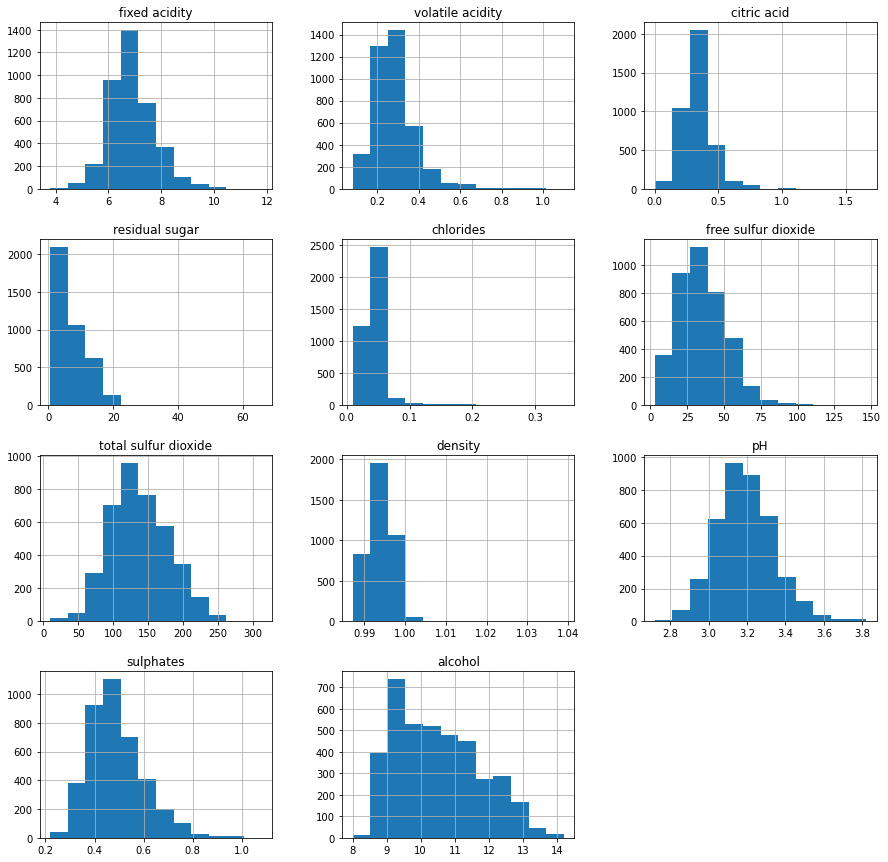

count    3918.000000
mean        5.871363
std         0.886913
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

In [5]:
# EDA

display(X_train.describe(include='all'))
X_train.hist(figsize=(15, 15), bins=12)  # bins ~= sqrt(N)
pl.show()

display(y_train.describe(include='all'))

Summary of X - Bivariate (column-pair) graphs:
Correlation matrix:


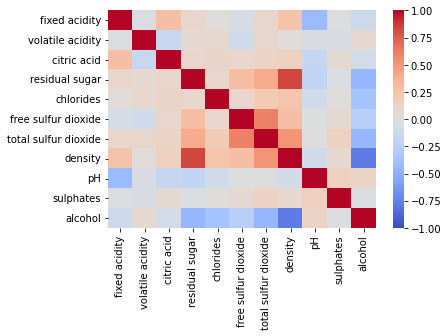

In [6]:
import seaborn as sns   # https://seaborn.pydata.org/

print('Summary of X - Bivariate (column-pair) graphs:')

print('Correlation matrix:')
corr = X.corr()
sns.heatmap( corr, cmap='coolwarm', vmax=1.0, vmin=-1.0 );
pl.show()

In [7]:
# print('Scatter plots:')
# scatter_matrix(X, figsize=(16, 16))
# pl.show()

In [8]:
# From the correlation matrix, we can see residual sugar is related to density. 
# Free sulfur dioxide is related to total sulfur dioxide. etc. 

In [9]:
#Classification problem: predicting the quality value (a single variable with 
#seven classes labeled 3, 4, 5, ..., 9) based on the values of all the other variables
#in the file (acidity, alcohol, pH, etc.)

In [10]:
# I'll be using SVC (support vector machine)

In [11]:
print('training model...')
modelName = SVC()
modelName.fit(X_train, y_train)  # train the model on the training data
print('done with training the model')

training model...
done with training the model


In [12]:
print('computing accuracy...')
y_predicted = modelName.predict(X_test)  # make predictions using the validation data 
print('Accuracy:', accuracy_score(y_test, y_predicted))

computing accuracy...
Accuracy: 0.44285714285714284


In [13]:
%matplotlib inline 
# variable_values = np.array([6.5, 0.24, 0.25, 1.79, 0.06, 20, 110, 1.02, 3.1, 0.5, 12]) # This just doesn't work
# test_point_x = variable_values.reshape(1, -1)
import pandas as pd
feature_names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
variable_values = np.array([6.5, 0.24, 0.25, 1.79, 0.06, 20, 110, 1.02, 3.1, 0.5, 12])
test_point_df = pd.DataFrame([variable_values], columns=feature_names)
print('Input for testing is: ')
print(test_point_df)
# print(type(test_point_df))
test_point_predicted_y = modelName.predict(test_point_df)
print(f"expected quality is: ")
print(test_point_predicted_y)

Input for testing is: 
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.5              0.24         0.25            1.79       0.06   

   free sulfur dioxide  total sulfur dioxide  density   pH  sulphates  alcohol  
0                 20.0                 110.0     1.02  3.1        0.5     12.0  
expected quality is: 
[6]


In [14]:
# SVC.fit(X_train, y_train)  # train the model on the training data
# y_predicted = SVC.predict(X_test)  # make predictions using the testing data
# # What does the error look like?
# y_actual = numpy.asarray(y_test)
# y_error = pandas.DataFrame(data=y_predicted - y_actual)
# results.append(y_error)
#     # result statistics
# print('method: mean (standard dev) max')
# msg = "%s: %f (%f) %f" % (name, y_error.mean(), y_error.std(), y_error.max())
# print(msg)
# # Plot outputs
# LL = min([min(y_predicted), min(y_actual)])
# UR = max([max(y_predicted), max(y_actual)])
# pl.title(name)
# pl.plot(y_predicted, y_actual,'ro')
# pl.plot([LL,UR],[LL,UR], 'g-')
# pl.xlabel('Predicted y')
# pl.ylabel('Actual y')
# pl.show()

In [15]:
# As you can see above, with a little bit complication, 
# I made the prediction of a wine's value based on its 11 features. 



In [16]:
#######################
###### problem 2 ######
#######################

In [17]:
print("hello")

hello


In [18]:
# Decision Tree
scoring = 'f1_macro'

print('Tuning model...')
selected_model = DecisionTreeClassifier()
hyperparameters = {'max_depth':[5, 6, 7, 10, 20], 'criterion':['gini', 'entropy']}
clf = GridSearchCV(selected_model, hyperparameters, cv=5, scoring=scoring, verbose=4) #verbose = 4 gives more details

clf.fit(X_train, y_train)
print("Best hyperparameters found on development set for Decision Tree:")
print(clf.best_params_)
tuned_model_DT = clf.best_estimator_

print(f'Decision tree has maximum depth {tuned_model_DT.tree_.max_depth}.')
y_pred = tuned_model_DT.predict(X_test)
print( 'f1_score is')
print( f1_score(y_test, y_pred, average='macro') )

Tuning model...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END .......criterion=gini, max_depth=5;, score=0.271 total time=   0.0s
[CV 2/5] END .......criterion=gini, max_depth=5;, score=0.222 total time=   0.0s
[CV 3/5] END .......criterion=gini, max_depth=5;, score=0.294 total time=   0.0s
[CV 4/5] END .......criterion=gini, max_depth=5;, score=0.219 total time=   0.0s
[CV 5/5] END .......criterion=gini, max_depth=5;, score=0.205 total time=   0.0s
[CV 1/5] END .......criterion=gini, max_depth=6;, score=0.291 total time=   0.0s
[CV 2/5] END .......criterion=gini, max_depth=6;, score=0.224 total time=   0.0s
[CV 3/5] END .......criterion=gini, max_depth=6;, score=0.291 total time=   0.0s
[CV 4/5] END .......criterion=gini, max_depth=6;, score=0.204 total time=   0.0s
[CV 5/5] END .......criterion=gini, max_depth=6;, score=0.249 total time=   0.0s
[CV 1/5] END .......criterion=gini, max_depth=7;, score=0.291 total time=   0.0s
[CV 2/5] END .......criterion=gi

In [19]:
# second model based on SVM

In [21]:
scoring = 'f1_macro'
print('Tuning model...')
selected_model = SVC()
hyperparameters = {'kernel':['linear', 'poly', 'rbf'], 'C':[0.01, 0.03]}
clf = GridSearchCV(selected_model, hyperparameters, cv=5, scoring=scoring, verbose=4) #verbose = 4 gives more details
# clf = SVC(kernel='linear', C=1000)

clf.fit(X_train, y_train)
print("Best hyperparameters found on development set for SVM:")
print(clf.best_params_)
tuned_model_DT = clf.best_estimator_

y_pred = tuned_model_DT.predict(X_test)
print( 'f1_score is')
print( f1_score(y_test, y_pred, average='macro') )

Tuning model...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END .............C=0.01, kernel=linear;, score=0.166 total time=   5.3s
[CV 2/5] END .............C=0.01, kernel=linear;, score=0.159 total time=   5.6s
[CV 3/5] END .............C=0.01, kernel=linear;, score=0.166 total time=   6.1s
[CV 4/5] END .............C=0.01, kernel=linear;, score=0.158 total time=   7.3s
[CV 5/5] END .............C=0.01, kernel=linear;, score=0.155 total time=   7.2s
[CV 1/5] END ...............C=0.01, kernel=poly;, score=0.089 total time=   0.8s
[CV 2/5] END ...............C=0.01, kernel=poly;, score=0.089 total time=   0.8s
[CV 3/5] END ...............C=0.01, kernel=poly;, score=0.089 total time=   0.8s
[CV 4/5] END ...............C=0.01, kernel=poly;, score=0.089 total time=   0.8s
[CV 5/5] END ...............C=0.01, kernel=poly;, score=0.089 total time=   0.8s
[CV 1/5] END ................C=0.01, kernel=rbf;, score=0.089 total time=   1.0s
[CV 2/5] END ................C=0.

In [22]:
####################
###### part 3 ######
####################

In [23]:
# As you could see from previous block, for decision tree, I used 2 hyperparameters: max_depth and criterion
# For SVM, I used kernel and C(misclassification )

In [24]:
####################
###### part 4 ######
####################

In [25]:
print('Reading list of scoring methods to use during model development ...')
scoring = 'accuracy'
print('done \n')

Reading list of scoring methods to use during model development ...
done 



In [26]:
seed = 42 # setting the seed allows for repeatability

print('Reading list of algorithms to train ...')
models = []
models.append(( 'DecisionTreeClassifier', DecisionTreeClassifier()))
models.append(( 'scaled_DecisionTreeClassifier', make_pipeline( MinMaxScaler(), DecisionTreeClassifier())))
models.append(( 'raw_SVM', SVC(random_state=seed) ))
models.append(( 'scaled_SVM', make_pipeline( MinMaxScaler(), SVC(random_state=seed) )  )) # Scaling is done with SVC as a single algorithm using make_pipeline
print('done \n')

Reading list of algorithms to train ...
done 



In [27]:
k4folds = 5
results = []
names = []
for name, model in models:   # Select each model in turn
    print(" ++ NOW WORKING ON ALGORITHM %s ++" % name)
    print("Splitting data into %s folds" % k4folds)
    kfold = model_selection.KFold(n_splits=k4folds, random_state=seed, shuffle=True)
    print("Training model on each split ...")
    cv_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring, verbose=3) # verbose = 3 is most detailed
    results.append(cv_results)
    names.append(name)
    msg = "algorithm %s %s results: mean = %f (std = %f)" % (name, scoring, cv_results.mean(), cv_results.std())
    print(msg)
    
print('done \n')

 ++ NOW WORKING ON ALGORITHM DecisionTreeClassifier ++
Splitting data into 5 folds
Training model on each split ...
[CV] END ................................ score: (test=0.571) total time=   0.1s
[CV] END ................................ score: (test=0.562) total time=   0.1s


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.2s remaining:    0.0s


[CV] END ................................ score: (test=0.537) total time=   0.1s
[CV] END ................................ score: (test=0.568) total time=   0.1s
[CV] END ................................ score: (test=0.538) total time=   0.1s
algorithm DecisionTreeClassifier accuracy results: mean = 0.555384 (std = 0.015017)
 ++ NOW WORKING ON ALGORITHM scaled_DecisionTreeClassifier ++
Splitting data into 5 folds
Training model on each split ...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.2s remaining:    0.0s


[CV] END ................................ score: (test=0.580) total time=   0.1s
[CV] END ................................ score: (test=0.557) total time=   0.1s
[CV] END ................................ score: (test=0.547) total time=   0.1s
[CV] END ................................ score: (test=0.566) total time=   0.1s
[CV] END ................................ score: (test=0.543) total time=   0.1s
algorithm scaled_DecisionTreeClassifier accuracy results: mean = 0.558701 (std = 0.013464)
 ++ NOW WORKING ON ALGORITHM raw_SVM ++
Splitting data into 5 folds
Training model on each split ...


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.0s remaining:    0.0s


[CV] END ................................ score: (test=0.555) total time=   1.0s


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    2.1s remaining:    0.0s


[CV] END ................................ score: (test=0.556) total time=   1.0s
[CV] END ................................ score: (test=0.539) total time=   1.0s
[CV] END ................................ score: (test=0.543) total time=   1.0s
algorithm scaled_SVM accuracy results: mean = 0.552827 (std = 0.011440)
done 



[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    5.1s finished


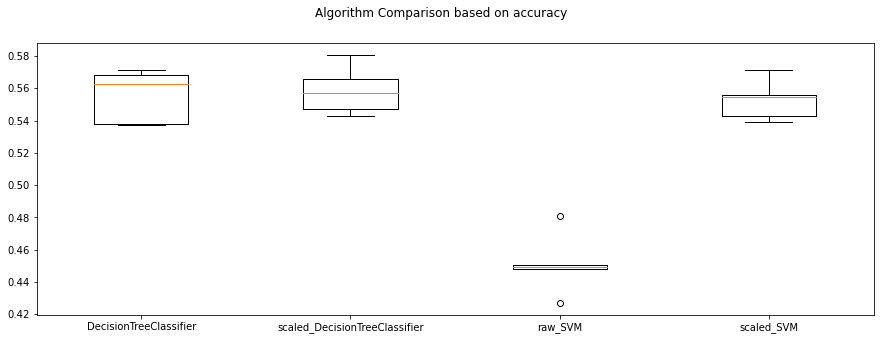

In [28]:
fig = pl.figure(figsize=(15,5))
fig.suptitle('Algorithm Comparison based on %s' % scoring)
ax = fig.add_subplot(111)
pl.boxplot(results)
ax.set_xticklabels(names)
pl.show()

In [ ]:
####################
###### part 5 ######
####################

In [30]:
# Dummy Classifier
scoring = 'f1_macro'

print('Tuning model...')
selected_model = DummyClassifier()
hyperparameters = {'strategy':['most_frequent', 'uniform']}
clf = GridSearchCV(selected_model, hyperparameters, cv=5, scoring=scoring, verbose=4) #verbose = 4 gives more details

clf.fit(X_train, y_train)
print("Best hyperparameters found on development set for Dummy Classifier:")
print(clf.best_params_)
tuned_model_DT = clf.best_estimator_

# print(f'Decision tree has maximum depth {tuned_model_DT.tree_.max_depth}.')
y_pred = tuned_model_DT.predict(X_test)
print( 'f1_score is')
print( f1_score(y_test, y_pred, average='macro') )

Tuning model...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV 1/5] END ............strategy=most_frequent;, score=0.089 total time=   0.0s
[CV 2/5] END ............strategy=most_frequent;, score=0.089 total time=   0.0s
[CV 3/5] END ............strategy=most_frequent;, score=0.089 total time=   0.0s
[CV 4/5] END ............strategy=most_frequent;, score=0.089 total time=   0.0s
[CV 5/5] END ............strategy=most_frequent;, score=0.089 total time=   0.0s
[CV 1/5] END ..................strategy=uniform;, score=0.112 total time=   0.0s
[CV 2/5] END ..................strategy=uniform;, score=0.106 total time=   0.0s
[CV 3/5] END ..................strategy=uniform;, score=0.091 total time=   0.0s
[CV 4/5] END ..................strategy=uniform;, score=0.101 total time=   0.0s
[CV 5/5] END ..................strategy=uniform;, score=0.122 total time=   0.0s
Best hyperparameters found on development set for Dummy Classifier:
{'strategy': 'uniform'}
f1_score is
0.10087744

In [31]:
# Conclusion: 
# Decision Tree -- using criterion entropy, max_depth 20, has score 36.33% accuracy
# scaled_DecisionTreeClassifier has average 55.87% 
# SVM -- using C 0.03, kernel linear, has score 19.02%
# scaled_SVM has accuracy 55.28%
# Dummy Classifier is only 10.09% accurate. Therefore, Decision Tree and SVM, 
# especially scaled versions, has a lot higher performance. 